In [74]:
import pandas as pd

In [75]:
pd.options.mode.chained_assignment = None
pd.set_option('display.max_columns', 60)

In [76]:
steam = pd.read_csv('games5.csv')
api = pd.read_csv('api_FINAL_FINAL.csv')

После считывания файлов, переназовем колонки, чтобы у всех были соответсвующие названия

In [77]:
steam.columns = [
    'link',
    'name',
    'release_date',
    'developers',
    'genre',
    'price',
    'discount',
    'dlc',
    'tags',
    'rating_steam',
    'reviews_count',
    'recent_rating',
    'recent_reviews_count'
]

Объединим датасеты по названию игры:

In [78]:
df = steam.merge(api, on='name', how='inner')
df.head()

,link,name,release_date,developers,genre,price,discount,dlc,tags,rating_steam,reviews_count_x,recent_rating,recent_reviews_count,rating,reviews_count_y,playtime,platforms,stores,esrb_rating,id_games,metacritic,achievements_count,a_count,series_count,dev_team_count
0,https://store.steampowered.com/app/730/Counter...,Counter-Strike 2,2012-08-21,Valve,"['Action', 'Free To Play']",Free To Play,0%,1.0,"['FPS', 'Shooter', 'Multiplayer', 'Competitive...",Very Positive,"9,521,157",Mostly Positive,"94,756",3.57,216.0,0.0,"['PC', 'Linux']",['Steam'],Mature,965470,NaN,0.0,0.0,0.0,1.0
1,https://store.steampowered.com/app/3321460/Cri...,Crimson Desert,NaN,Pearl Abyss,"['Экшены', 'Приключенческие игры']","69,99€",0%,1.0,"['Открытый мир', 'Экшен', 'Для одного игрока',...",Очень положительные,78 700,NaN,NaN,3.68,19.0,0.0,"['PC', 'PlayStation 5', 'Xbox One', 'PlayStati...",NaN,NaN,529829,NaN,0.0,0.0,0.0,0.0
2,https://store.steampowered.com/app/2868840/Sla...,Slay the Spire 2,2026-03-05,Mega Crit,"['Indie', 'Strategy', 'Early Access']","22,99€",0%,0.0,"['Strategy', 'Roguelike', 'Card Game', 'Deckbu...",Very Positive,"98,132",Mostly Positive,"85,557",0.00,5.0,7.0,"['PC', 'macOS', 'Linux']",['Steam'],Everyone 10+,994601,NaN,0.0,0.0,1.0,1.0
3,https://store.steampowered.com/app/2050650/Res...,Resident Evil 4,2023-03-24,"CAPCOM Co., Ltd.","['Action', 'Adventure']","100,24€",-60%,27.0,"['Horror', 'Action', 'Survival Horror', 'Third...",Overwhelmingly Positive,"157,050",Overwhelmingly Positive,"7,371",4.58,635.0,24.0,"['PC', 'PlayStation 5', 'PlayStation 4', 'Xbox...","['Steam', 'PlayStation Store']",Mature,795632,NaN,34.0,0.0,28.0,7.0
4,https://store.steampowered.com/app/1172470/Ape...,Apex Legends™,2020-11-04,Respawn,"['Action', 'Adventure', 'Free To Play']",Free To Play,0%,0.0,"['Free to Play', 'Battle Royale', 'Multiplayer...",Mixed,"1,040,934",Mixed,"8,265",3.63,2439.0,5.0,"['PC', 'Xbox One', 'PlayStation 4', 'Nintendo ...","['Steam', 'PlayStation Store', 'Xbox Store', '...",Teen,290856,80.0,12.0,21.0,1.0,3.0


Узнаем основные данные по получившемуся датафрейму:

In [79]:
print("Размеры датасета: ", df.shape)
print("Колонки датасета: ", df.columns)

Размеры датасета:  (9672, 25)
Колонки датасета:  Index(['link', 'name', 'release_date', 'developers', 'genre', 'price',
       'discount', 'dlc', 'tags', 'rating_steam', 'reviews_count_x',
       'recent_rating', 'recent_reviews_count', 'rating', 'reviews_count_y',
       'playtime', 'platforms', 'stores', 'esrb_rating', 'id_games',
       'metacritic', 'achievements_count', 'a_count', 'series_count',
       'dev_team_count'],
      dtype='object')


In [80]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9672 entries, 0 to 9671
Data columns (total 25 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   link                  9672 non-null   object 
 1   name                  9671 non-null   object 
 2   release_date          9665 non-null   object 
 3   developers            9668 non-null   object 
 4   genre                 9672 non-null   object 
 5   price                 9632 non-null   object 
 6   discount              9556 non-null   object 
 7   dlc                   9670 non-null   float64
 8   tags                  9672 non-null   object 
 9   rating_steam          3734 non-null   object 
 10  reviews_count_x       3734 non-null   object 
 11  recent_rating         3569 non-null   object 
 12  recent_reviews_count  3569 non-null   object 
 13  rating                9672 non-null   float64
 14  reviews_count_y       9672 non-null   float64
 15  playtime             

Так как мы хотим предсказать успешность нашей игры, то в качестве целевой переменной можно рассмотреть либо rating_steam, либо rating с сайта RAWG. Видим, что у нас в rating_steam довольно много пропусков, поэтому лучше будет взять признак rating для предсказания

In [81]:
df.isna().sum()

,0
link,0
name,1
release_date,7
developers,4
genre,0
price,40
discount,116
dlc,2
tags,0
rating_steam,5938


In [82]:
#вы скажете гпт а я скажу это копипаст из семинара юры

def missing_values_table(df):
    """
    Функция возвращает резюме по пропущенным значениям
    """
    # Общее число пропусков
    mis_val = df.isnull().sum()

    # Процент пропусков
    mis_val_percent = 100 * df.isnull().sum() / len(df)

    # Создадит таблицу с результатом
    mis_val_table = pd.concat([mis_val, mis_val_percent], axis=1)

    # Переименнуем колонки
    mis_val_table_ren_columns = mis_val_table.rename(
    columns = {0 : 'Missing Values', 1 : '% of Total Values'})

    # Отсортируем по проценту пропущенных значений
    mis_val_table_ren_columns = mis_val_table_ren_columns[
        mis_val_table_ren_columns.iloc[:,1] != 0].sort_values(
    '% of Total Values', ascending=False).round(1)

    # Выведем некоторую информацию
    print ("Your selected dataframe has " + str(df.shape[1]) + " columns.\n"
        "There are " + str(mis_val_table_ren_columns.shape[0]) +
            " columns that have missing values.")

    return mis_val_table_ren_columns

In [83]:
missing_values_table(df)

Your selected dataframe has 25 columns.
There are 17 columns that have missing values.


,Missing Values,% of Total Values
metacritic,7090,73.3
esrb_rating,6823,70.5
recent_rating,6103,63.1
recent_reviews_count,6103,63.1
reviews_count_x,5938,61.4
rating_steam,5938,61.4
a_count,1156,12.0
stores,442,4.6
discount,116,1.2
series_count,51,0.5


In [84]:
missing_df = missing_values_table(df)
missing_columns = list(missing_df[missing_df['% of Total Values'] > 50].index)

print('We will remove %d columns.' % len(missing_columns))

Your selected dataframe has 25 columns.
There are 17 columns that have missing values.
We will remove 6 columns.


Значит планируем удалить 6 колонок, так как в них отсутсвует более 50% данных, а именно metacritic, esrb_rating, recent_rating, recent_reviews_count, rating_steam, reviews_count_x
Эти признаки содержат слишком много пропусков, поэтому их использование может исказить анализ, а также их удаление не приведет к потери значимых данных так их большая чать отсутвует, кроме того у нас есть схожие столбцы, следовательно - удаляем


In [85]:
df = df.drop(columns = list(missing_columns))

In [86]:
df.shape

(9672, 19)

In [87]:
missing_values_table(df)

Your selected dataframe has 19 columns.
There are 11 columns that have missing values.


,Missing Values,% of Total Values
a_count,1156,12.0
stores,442,4.6
discount,116,1.2
series_count,51,0.5
price,40,0.4
platforms,34,0.4
release_date,7,0.1
developers,4,0.0
dev_team_count,3,0.0
dlc,2,0.0


Колонки, где пропусков меньше 1,5%, заполнять не будем. Будем считать, что эти пропуски носят случайный характер и их доля слишком мала, чтобы значимо повлиять на анализ, а заполнение этих пропусков может наоборот внести лишний шум, поэтому удалим строки с этими пропусками

In [88]:
missing_df = missing_values_table(df)
cols_miss = list(missing_df[missing_df['% of Total Values'] <= 1.5].index)
cols_miss

Your selected dataframe has 19 columns.
There are 11 columns that have missing values.


['discount',
 'series_count',
 'price',
 'platforms',
 'release_date',
 'developers',
 'dev_team_count',
 'dlc',
 'name']

In [89]:
df = df.dropna(subset=cols_miss)

In [90]:
df.shape

(9436, 19)

Осталось 2 признака, пропуски в которых необходимо заполнить.

"a_count" - показатель пострелизного развития, те сколько переизданий и всяких продуктов было создано вокруг игры.
Пропуски заменим на 0, так как пропуск как раз и озачает, что доп контент отсутсвет.

"stores" это площадки на которых есть игра, то есть заменим пропуски на пустые скобки, так как по сути получается, что информация о площадках отсуствует.

In [91]:
df["a_count"] = df["a_count"].fillna(0)

In [92]:
df["stores"] = df["stores"].fillna('[]')

In [93]:
df.isna().any().any()

np.False_

Отлично, в итоге у нас не осталось пропусков, перейдем к дубликатам

In [94]:
df.duplicated().sum()

np.int64(48)

In [95]:
df[df.duplicated(keep=False)]

,link,name,release_date,developers,genre,price,discount,dlc,tags,rating,reviews_count_y,playtime,platforms,stores,id_games,achievements_count,a_count,series_count,dev_team_count
880,https://store.steampowered.com/app/612470/Bio_...,Bio Inc. Redemption,2018-03-08,DryGin Studios,"['Indie', 'Simulation', 'Strategy']","12,99€",-92%,0.0,"['Medical Sim', 'Outbreak Sim', 'Simulation', ...",3.62,39.0,3.0,"['PC', 'PlayStation 5', 'PlayStation 4', 'Xbox...","['Steam', 'PlayStation Store', 'Xbox Store', '...",23417,41.0,0.0,0.0,0.0
881,https://store.steampowered.com/app/612470/Bio_...,Bio Inc. Redemption,2018-03-08,DryGin Studios,"['Indie', 'Simulation', 'Strategy']","12,99€",-92%,0.0,"['Medical Sim', 'Outbreak Sim', 'Simulation', ...",3.62,39.0,3.0,"['PC', 'PlayStation 5', 'PlayStation 4', 'Xbox...","['Steam', 'PlayStation Store', 'Xbox Store', '...",23417,41.0,0.0,0.0,0.0
882,https://store.steampowered.com/app/1020790/NAR...,NARUTO X BORUTO Ultimate Ninja STORM CONNECTIONS,2023-11-16,"CyberConnect2 Co., Ltd.","['Action', 'Adventure']","84,99€",-60%,9.0,"['Action', 'Anime', 'Adventure', '3D Fighter',...",3.33,12.0,0.0,"['PC', 'PlayStation 5', 'Xbox One', 'PlayStati...",[],934440,0.0,0.0,17.0,0.0
883,https://store.steampowered.com/app/1020790/NAR...,NARUTO X BORUTO Ultimate Ninja STORM CONNECTIONS,2023-11-16,"CyberConnect2 Co., Ltd.","['Action', 'Adventure']","84,99€",-60%,9.0,"['Action', 'Anime', 'Adventure', '3D Fighter',...",3.33,12.0,0.0,"['PC', 'PlayStation 5', 'Xbox One', 'PlayStati...",[],934440,0.0,0.0,17.0,0.0
894,https://store.steampowered.com/app/1020790/NAR...,NARUTO X BORUTO Ultimate Ninja STORM CONNECTIONS,2023-11-16,"CyberConnect2 Co., Ltd.","['Action', 'Adventure']","84,99€",-60%,9.0,"['Action', 'Anime', 'Adventure', '3D Fighter',...",3.33,12.0,0.0,"['PC', 'PlayStation 5', 'Xbox One', 'PlayStati...",[],934440,0.0,0.0,17.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9506,https://store.steampowered.com/app/628740/Mr_S...,Mr. Saitou,2023-03-23,Laura Shigihara,"['Adventure', 'Indie', 'RPG']","11,79€",0%,1.0,"['Story Rich', 'Fantasy', 'Adventure', 'RPG', ...",0.00,3.0,3.0,"['PC', 'macOS', 'Linux']",['Steam'],944923,10.0,0.0,0.0,0.0
9509,https://store.steampowered.com/app/770390/Drau...,Draugen,2019-05-29,Red Thread Games,"['Adventure', 'Indie']","19,99€",0%,3.0,"['Story Rich', 'Mystery', 'Atmospheric', 'Firs...",3.50,125.0,4.0,"['PC', 'Xbox One', 'PlayStation 4']","['Steam', 'PlayStation Store', 'Xbox Store', '...",264721,7.0,0.0,0.0,0.0
9510,https://store.steampowered.com/app/770390/Drau...,Draugen,2019-05-29,Red Thread Games,"['Adventure', 'Indie']","19,99€",0%,3.0,"['Story Rich', 'Mystery', 'Atmospheric', 'Firs...",3.50,125.0,4.0,"['PC', 'Xbox One', 'PlayStation 4']","['Steam', 'PlayStation Store', 'Xbox Store', '...",264721,7.0,0.0,0.0,0.0
9629,https://store.steampowered.com/app/243040/Star...,Startopia,2001-06-19,"My Little Planet Ltd, Mucky Foot Productions Ltd",['Simulation'],"5,69€",0%,0.0,"['Simulation', 'Management', 'Strategy', 'Funn...",3.65,43.0,1.0,['PC'],"['Steam', 'GOG']",22869,0.0,0.0,1.0,0.0


Видим, что строки у нас полностью копируются и не несут никакой новой и нужной информации, поэтому мы можем их удалить без потерь.

In [96]:
df = df.drop_duplicates()

In [97]:
df.duplicated().sum()

np.int64(0)

In [98]:
df.to_csv('data.csv', index=False)

In [99]:
data = df
data

,link,name,release_date,developers,genre,price,discount,dlc,tags,rating,reviews_count_y,playtime,platforms,stores,id_games,achievements_count,a_count,series_count,dev_team_count
0,https://store.steampowered.com/app/730/Counter...,Counter-Strike 2,2012-08-21,Valve,"['Action', 'Free To Play']",Free To Play,0%,1.0,"['FPS', 'Shooter', 'Multiplayer', 'Competitive...",3.57,216.0,0.0,"['PC', 'Linux']",['Steam'],965470,0.0,0.0,0.0,1.0
2,https://store.steampowered.com/app/2868840/Sla...,Slay the Spire 2,2026-03-05,Mega Crit,"['Indie', 'Strategy', 'Early Access']","22,99€",0%,0.0,"['Strategy', 'Roguelike', 'Card Game', 'Deckbu...",0.00,5.0,7.0,"['PC', 'macOS', 'Linux']",['Steam'],994601,0.0,0.0,1.0,1.0
3,https://store.steampowered.com/app/2050650/Res...,Resident Evil 4,2023-03-24,"CAPCOM Co., Ltd.","['Action', 'Adventure']","100,24€",-60%,27.0,"['Horror', 'Action', 'Survival Horror', 'Third...",4.58,635.0,24.0,"['PC', 'PlayStation 5', 'PlayStation 4', 'Xbox...","['Steam', 'PlayStation Store']",795632,34.0,0.0,28.0,7.0
4,https://store.steampowered.com/app/1172470/Ape...,Apex Legends™,2020-11-04,Respawn,"['Action', 'Adventure', 'Free To Play']",Free To Play,0%,0.0,"['Free to Play', 'Battle Royale', 'Multiplayer...",3.63,2439.0,5.0,"['PC', 'Xbox One', 'PlayStation 4', 'Nintendo ...","['Steam', 'PlayStation Store', 'Xbox Store', '...",290856,12.0,21.0,1.0,3.0
5,https://store.steampowered.com/app/230410/Warf...,Warframe,2013-03-25,Digital Extremes,"['Action', 'RPG', 'Free To Play']",Free To Play,0%,17.0,"['Free to Play', 'Looter Shooter', 'Action RPG...",3.42,2128.0,8.0,"['PC', 'PlayStation 5', 'Xbox One', 'PlayStati...","['Steam', 'PlayStation Store', 'Xbox Store', '...",766,259.0,0.0,0.0,14.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9666,https://store.steampowered.com/app/3135260/Blu...,Blueman,2025-12-11,Ankoku,"['Indie', 'Simulation']","7,79€",0%,0.0,"['Job Simulator', 'Puzzle', 'Simulation', 'Hid...",0.00,0.0,0.0,['Web'],['itch.io'],760886,0.0,0.0,0.0,0.0
9668,https://store.steampowered.com/app/1497230/Cau...,Cauldrons of War - Stalingrad,2021-09-10,Maestro Cinetik,['Strategy'],"14,99€",-70%,0.0,"['Strategy', 'Grand Strategy', 'World War II',...",0.00,0.0,1.0,['PC'],"['Steam', 'itch.io']",519882,0.0,0.0,0.0,0.0
9669,https://store.steampowered.com/app/1161490/Mot...,MotoGP™20,2020-04-23,Milestone S.r.l.,"['Racing', 'Simulation', 'Sports']","19,99€",0%,1.0,"['Racing', 'Sports', 'Simulation', 'Motorbike'...",3.38,21.0,4.0,"['PC', 'Xbox One', 'PlayStation 4', 'Nintendo ...","['Steam', 'PlayStation Store', 'Xbox Store', '...",413881,54.0,0.0,14.0,0.0
9670,https://store.steampowered.com/app/1611430/The...,The Bridge Curse Road to Salvation,2022-08-24,SOFTSTAR ENTERTAINMENT,"['Action', 'Adventure', 'RPG']","16,79€",0%,1.0,"['Horror', 'First-Person', 'Puzzle', 'Explorat...",0.00,2.0,3.0,"['PC', 'PlayStation 5', 'Xbox One', 'PlayStati...","['Steam', 'PlayStation Store', 'Xbox Store', '...",840800,22.0,0.0,1.0,0.0


Проведем анализ того, как различные признаки игры влияют на ее успех.

Для начала посмотрим на распределение самой целевой переменной.

In [100]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from IPython.core.pylabtools import figsize

In [101]:
%matplotlib inline

#plt.rcParams['font.size'] = 24

pd.options.mode.chained_assignment = None
pd.set_option('display.max_columns', 60)

#sns.set(font_scale = 2)

Text(0, 0.5, 'Score')

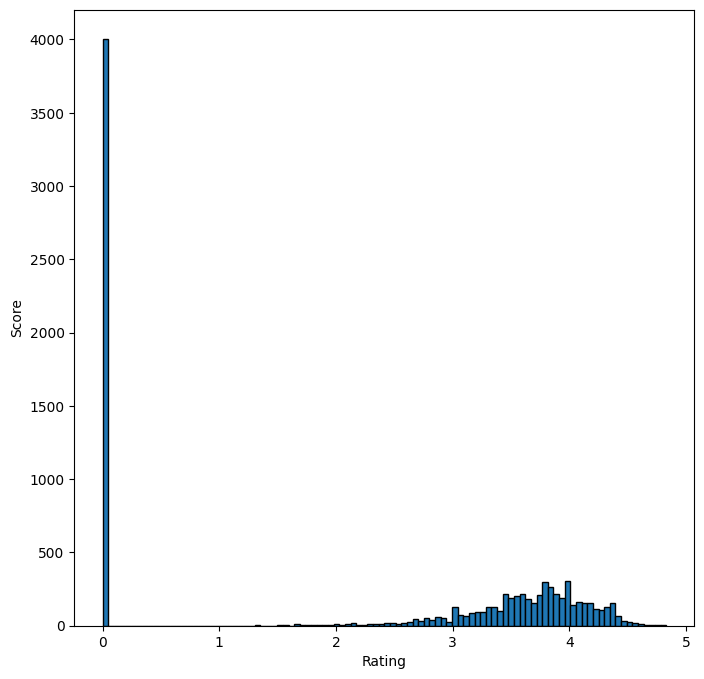

In [102]:
figsize(8, 8)

# Построим гистограмму распределения столбца score, воспользовавшись функцией plt.hist, указав число бинов (например) 100
plt.hist(data['rating'], bins = 100, edgecolor = 'k')

plt.xlabel('Rating')
plt.ylabel('Score')
#plt.style.use('fivethirtyeight')

In [103]:
data['rating'].describe()

,rating
count,9388.000000
mean,2.091584
std,1.846981
min,0.000000
25%,0.000000
50%,3.060000
75%,3.790000
max,4.830000


Довольно много нулей. Гипотеза: причиной этого является то, что когда на rawg 0 отзывов, то рейтинг тоже 0. Проверим совпадает ли количество игр, где нет отзывов, и количество нулей в рейтинге.

In [104]:
data[data['rating']==0]

,link,name,release_date,developers,genre,price,discount,dlc,tags,rating,reviews_count_y,playtime,platforms,stores,id_games,achievements_count,a_count,series_count,dev_team_count
2,https://store.steampowered.com/app/2868840/Sla...,Slay the Spire 2,2026-03-05,Mega Crit,"['Indie', 'Strategy', 'Early Access']","22,99€",0%,0.0,"['Strategy', 'Roguelike', 'Card Game', 'Deckbu...",0.0,5.0,7.0,"['PC', 'macOS', 'Linux']",['Steam'],994601,0.0,0.0,1.0,1.0
37,https://store.steampowered.com/app/3224770/Uma...,Umamusume: Pretty Derby,2025-06-24,"Cygames, Inc.","['Simulation', 'Sports', 'Free To Play']",Free To Play,0%,0.0,"['Anime', 'Horses', 'Cute', 'Free to Play', 'G...",0.0,1.0,2.0,['PC'],['Steam'],1005745,20.0,0.0,0.0,0.0
41,https://store.steampowered.com/app/4069520/Sup...,Super Battle Golf,2026-02-19,Brimstone,"['Casual', 'Indie', 'Sports']","7,99€",-30%,0.0,"['Multiplayer', 'Online Co-Op', 'Co-op', 'Spor...",0.0,1.0,10.0,['PC'],['Steam'],1016076,33.0,0.0,0.0,0.0
45,https://store.steampowered.com/app/1476970/Idl...,IdleOn,2025-11-06,Lavaflame2,"['Casual', 'Indie', 'Massively Multiplayer', '...",Free To Play,0%,0.0,"['Idler', 'Free to Play', 'MMORPG', 'Pixel Gra...",0.0,1.0,0.0,['iOS'],['App Store'],852857,0.0,0.0,0.0,0.0
48,https://store.steampowered.com/app/636040/Pixe...,Pixel Worlds: MMO Sandbox,2017-01-21,Social First Oy,"['Adventure', 'Indie', 'Massively Multiplayer'...",Free To Play,0%,0.0,"['Free to Play', 'Pixel Graphics', 'Sandbox', ...",0.0,1.0,0.0,['iOS'],['App Store'],396877,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9663,https://store.steampowered.com/app/1446350/You...,You Will Die Here Tonight,2023-10-31,Spiral Bound Interactive LLC,"['Action', 'Adventure', 'Indie', 'RPG']","19,50€",0%,1.0,"['Dark', 'Psychological Horror', 'Zombies', 'C...",0.0,1.0,10.0,['PC'],"['Steam', 'GOG']",968736,15.0,0.0,0.0,0.0
9664,https://store.steampowered.com/app/2063530/Met...,Methods: The Canada Files,2026-03-05,LockedOn Games,"['Adventure', 'Casual', 'Indie', 'RPG', 'Strat...","19,50€",0%,1.0,"['Investigation', 'Casual', '2D', 'Detective',...",0.0,0.0,0.0,"['PC', 'macOS', 'Linux']",['Steam'],917856,0.0,0.0,0.0,0.0
9666,https://store.steampowered.com/app/3135260/Blu...,Blueman,2025-12-11,Ankoku,"['Indie', 'Simulation']","7,79€",0%,0.0,"['Job Simulator', 'Puzzle', 'Simulation', 'Hid...",0.0,0.0,0.0,['Web'],['itch.io'],760886,0.0,0.0,0.0,0.0
9668,https://store.steampowered.com/app/1497230/Cau...,Cauldrons of War - Stalingrad,2021-09-10,Maestro Cinetik,['Strategy'],"14,99€",-70%,0.0,"['Strategy', 'Grand Strategy', 'World War II',...",0.0,0.0,1.0,['PC'],"['Steam', 'itch.io']",519882,0.0,0.0,0.0,0.0


In [105]:
data[data['rating']==0]['name'].count()

np.int64(4003)

In [106]:
data[data['reviews_count_y']==0]['name'].count()

np.int64(1965)

In [107]:
data[(data['reviews_count_y']==0) & (data['rating']==0)]['name'].count()

np.int64(1965)

Видим, что у нас есть игры, у которых нет оценок и из-за этого рейтинг значится как 0, хотя это не значит, что игра низко оценена. Удалим эти игры, так как они не будут информативны для нашего анализа.

In [108]:
data = data[data['reviews_count_y'] > 0]

In [109]:
data[data['reviews_count_y']==0]['name'].count()

np.int64(0)

In [110]:
data[data['rating']==0]['name'].count()

np.int64(2038)

Text(0, 0.5, 'count')

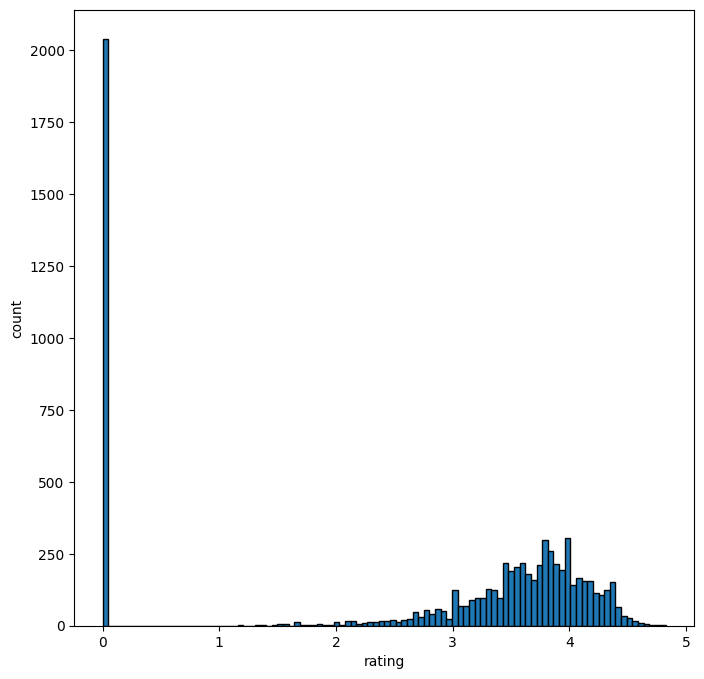

In [111]:
figsize(8, 8)

# Построим гистограмму распределения столбца score, воспользовавшись функцией plt.hist, указав число бинов (например) 100
plt.hist(data['rating'], bins = 100, edgecolor = 'k')

plt.xlabel('rating')
plt.ylabel('count')
#plt.style.use('fivethirtyeight')

Стало лучше, но выброс у оценки 0 сохранился. Видимо это потому, что некоторые игры оценивает маленькое количество пользователей (<10) и ставит оценку 0. Но, значит, такая игра не возымела успех и популярность у пользователей, что как раз важно для нашего анализа.

In [112]:
data.to_csv('data3.csv', index=False)

In [113]:
data['reviews_count_y'].describe()

,reviews_count_y
count,7423.000000
mean,166.050653
std,410.937953
min,1.000000
25%,5.000000
50%,22.000000
75%,119.000000
max,7299.000000


Стоит отметить, что нельзя объективно судить об игре из-за большой разнице в количестве оценок, так как чье-то мнение может быть субъективно. Мы решили добавить новую переменную score, по которой будем оценивать успешность игры.

In [114]:
data['rating_norm'] = data['rating']/data['rating'].max() # нормируем рейтинг, чтобы привести к диапазону 0-1 и сопоставить с количеством отзывов
data['reviews_log'] = np.log1p(data['reviews_count_y']) # тк в количестве отзывов есть очень большие значения и сильный разброс, устаканим это все логарифмиррованием
data['reviews_norm'] = data['reviews_log']/data['reviews_log'].max() # нормируем количество отзывов, чтобы привести к диапазону 0-1 и сопоставить с рейтингом
data['score'] = 0.65*data['reviews_norm']+0.35*data['rating_norm']
data

,link,name,release_date,developers,genre,price,discount,dlc,tags,rating,reviews_count_y,playtime,platforms,stores,id_games,achievements_count,a_count,series_count,dev_team_count,rating_norm,reviews_log,reviews_norm,score
0,https://store.steampowered.com/app/730/Counter...,Counter-Strike 2,2012-08-21,Valve,"['Action', 'Free To Play']",Free To Play,0%,1.0,"['FPS', 'Shooter', 'Multiplayer', 'Competitive...",3.57,216.0,0.0,"['PC', 'Linux']",['Steam'],965470,0.0,0.0,0.0,1.0,0.739130,5.379897,0.604780,0.651803
2,https://store.steampowered.com/app/2868840/Sla...,Slay the Spire 2,2026-03-05,Mega Crit,"['Indie', 'Strategy', 'Early Access']","22,99€",0%,0.0,"['Strategy', 'Roguelike', 'Card Game', 'Deckbu...",0.00,5.0,7.0,"['PC', 'macOS', 'Linux']",['Steam'],994601,0.0,0.0,1.0,1.0,0.000000,1.791759,0.201420,0.130923
3,https://store.steampowered.com/app/2050650/Res...,Resident Evil 4,2023-03-24,"CAPCOM Co., Ltd.","['Action', 'Adventure']","100,24€",-60%,27.0,"['Horror', 'Action', 'Survival Horror', 'Third...",4.58,635.0,24.0,"['PC', 'PlayStation 5', 'PlayStation 4', 'Xbox...","['Steam', 'PlayStation Store']",795632,34.0,0.0,28.0,7.0,0.948240,6.455199,0.725660,0.803563
4,https://store.steampowered.com/app/1172470/Ape...,Apex Legends™,2020-11-04,Respawn,"['Action', 'Adventure', 'Free To Play']",Free To Play,0%,0.0,"['Free to Play', 'Battle Royale', 'Multiplayer...",3.63,2439.0,5.0,"['PC', 'Xbox One', 'PlayStation 4', 'Nintendo ...","['Steam', 'PlayStation Store', 'Xbox Store', '...",290856,12.0,21.0,1.0,3.0,0.751553,7.799753,0.876807,0.832968
5,https://store.steampowered.com/app/230410/Warf...,Warframe,2013-03-25,Digital Extremes,"['Action', 'RPG', 'Free To Play']",Free To Play,0%,17.0,"['Free to Play', 'Looter Shooter', 'Action RPG...",3.42,2128.0,8.0,"['PC', 'PlayStation 5', 'Xbox One', 'PlayStati...","['Steam', 'PlayStation Store', 'Xbox Store', '...",766,259.0,0.0,0.0,14.0,0.708075,7.663408,0.861480,0.807788
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9663,https://store.steampowered.com/app/1446350/You...,You Will Die Here Tonight,2023-10-31,Spiral Bound Interactive LLC,"['Action', 'Adventure', 'Indie', 'RPG']","19,50€",0%,1.0,"['Dark', 'Psychological Horror', 'Zombies', 'C...",0.00,1.0,10.0,['PC'],"['Steam', 'GOG']",968736,15.0,0.0,0.0,0.0,0.000000,0.693147,0.077920,0.050648
9665,https://store.steampowered.com/app/1298140/Fob...,Fobia - St. Dinfna Hotel,2022-06-28,Pulsatrix Studios,['Indie'],"24,99€",0%,0.0,"['Indie', 'Survival Horror', 'Puzzle', 'Violen...",3.27,15.0,4.0,"['PC', 'Xbox One', 'PlayStation 4', 'Xbox Seri...","['Steam', 'itch.io']",484814,23.0,0.0,0.0,0.0,0.677019,2.772589,0.311680,0.439548
9669,https://store.steampowered.com/app/1161490/Mot...,MotoGP™20,2020-04-23,Milestone S.r.l.,"['Racing', 'Simulation', 'Sports']","19,99€",0%,1.0,"['Racing', 'Sports', 'Simulation', 'Motorbike'...",3.38,21.0,4.0,"['PC', 'Xbox One', 'PlayStation 4', 'Nintendo ...","['Steam', 'PlayStation Store', 'Xbox Store', '...",413881,54.0,0.0,14.0,0.0,0.699793,3.091042,0.347479,0.470789
9670,https://store.steampowered.com/app/1611430/The...,The Bridge Curse Road to Salvation,2022-08-24,SOFTSTAR ENTERTAINMENT,"['Action', 'Adventure', 'RPG']","16,79€",0%,1.0,"['Horror', 'First-Person', 'Puzzle', 'Explorat...",0.00,2.0,3.0,"['PC', 'PlayStation 5', 'Xbox One', 'PlayStati...","['Steam', 'PlayStation Store', 'Xbox Store', '...",840800,22.0,0.0,1.0,0.0,0.000000,1.098612,0.123500,0.080275


Берем количество отзывов с большим весом, потому что они показывают, сколько людей реально играли, а это главный признак успеха, а рейтинг добавляем с меньшим весом, чтобы учитывать качество, но не считать успешной игру, в которую почти никто не играл.

In [115]:
data.to_csv('data4.csv', index=False)

Text(0, 0.5, 'count')

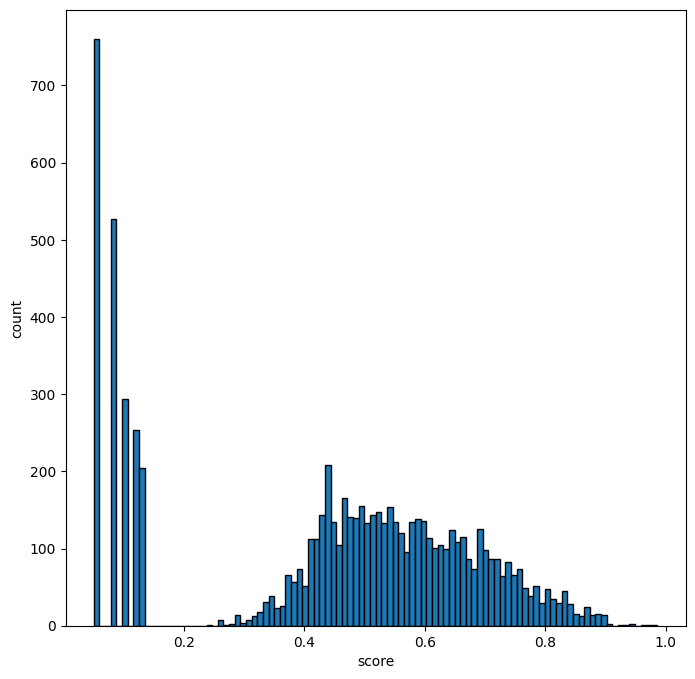

In [116]:
figsize(8, 8)

plt.hist(data['score'], bins = 100, edgecolor = 'k')

plt.xlabel('score')
plt.ylabel('count')

Выглядит приятнее